In [1]:
%pip install pandas numpy spacy matplotlib plotly scikit-learn beautifulsoup4 nltk lda optuna optuna-dashboard

Note: you may need to restart the kernel to use updated packages.


In [2]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------------------------------------ -- 12.1/12.8 MB 68.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 61.8 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:

import random
import re
import time
import warnings

import joblib
import lda
import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd
import pyLDAvis
import seaborn as sns
import spacy
from bs4 import BeautifulSoup
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\spacy\cli\_util.py:23: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\weasel\util\config.py:8: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string


## LDA

In [4]:
# Carga de datos
test = pd.read_csv("data/research-articles/test.csv")
train = pd.read_csv("data/research-articles/train.csv")

display(test.head())
display(train.head())

,ID,TITLE,ABSTRACT
0,20973,Closed-form Marginal Likelihood in Gamma-Poiss...,We present novel understandings of the Gamma...
1,20974,Laboratory mid-IR spectra of equilibrated and ...,Meteorites contain minerals from Solar Syste...
2,20975,Case For Static AMSDU Aggregation in WLANs,Frame aggregation is a mechanism by which mu...
3,20976,The $Gaia$-ESO Survey: the inner disk intermed...,Milky Way open clusters are very diverse in ...
4,20977,Witness-Functions versus Interpretation-Functi...,Proving that a cryptographic protocol is cor...


,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


In [6]:
train.dtypes

ID                       int64
TITLE                   object
ABSTRACT                object
Computer Science         int64
Physics                  int64
Mathematics              int64
Statistics               int64
Quantitative Biology     int64
Quantitative Finance     int64
dtype: object

In [7]:
# trabajamos con menos documentos, para facilitar la ejecución y bajar tiempos de procesamiento
train_small = train.sample(n=500, random_state=42)
documents = list(train_small.ABSTRACT.values)  # utilizaremos solo la column Abstract como los documentos

print(documents[0])  # como ejemplo imprimimos el primer documento

  Layer normalization is a recently introduced technique for normalizing the
activities of neurons in deep neural networks to improve the training speed and
stability. In this paper, we introduce a new layer normalization technique
called Dynamic Layer Normalization (DLN) for adaptive neural acoustic modeling
in speech recognition. By dynamically generating the scaling and shifting
parameters in layer normalization, DLN adapts neural acoustic models to the
acoustic variability arising from various factors such as speakers, channel
noises, and environments. Unlike other adaptive acoustic models, our proposed
approach does not require additional adaptation data or speaker information
such as i-vectors. Moreover, the model size is fixed as it dynamically
generates adaptation parameters. We apply our proposed DLN to deep
bidirectional LSTM acoustic models and evaluate them on two benchmark datasets
for large vocabulary ASR experiments: WSJ and TED-LIUM release 2. The
experimental results s

In [8]:
nltk.download('stopwords')
stop_words_en = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zeldan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
## Cargar modelo de spaCy en ingles
nlp = spacy.load("en_core_web_sm")
custom_stops = {
    "research", "paper", "study", "result", "analysis", "method",
    "approach", "system", "data", "based", "user", "model"
}


def remove_html(_text):
    no_html_txt = BeautifulSoup(_text, "html.parser").getText(separator=" ")
    return no_html_txt


def clear_text(_text):
    #Eliminar etiquetas html
    _text = remove_html(_text)

    # Limpieza basica del texto
    ## Eliminar bloques de código entre ```
    _text = re.sub(r"```.*?```", " ", _text, flags=re.DOTALL)

    ##Eliminar etiquetas markdown (#, *, _, >, etc.)
    _text = re.sub(r"[#*_>\-`~]", " ", _text)

    ##Eliminar URLs y direcciones tipo http o www
    _text = re.sub(r"http\S+|www\S+", " ", _text)

    ##Eliminar etiquetas HTML o imágenes ![texto](url)
    _text = re.sub(r"!\[.*?\]\(.*?\)", " ", _text)

    ##quitar números y caracteres no alfabéticos (mantener letras acentuadas)
    texto = re.sub(r"[^a-zA-ZáéíóúñÁÉÍÓÚüÜ\s]", " ", _text)

    ##texto a minusculas para hacer mejores comparaciones
    _text = _text.lower()

    # Eliminacion de stopwords
    doc = nlp(_text)  # retorna un objeto con estructura de tokens, lemas, etiquetas (analizado)

    tokens = []  # para guardar palablas sin stopwords
    for word in doc:
        if (
                word.is_alpha and
                not word.is_punct and
                not word.is_space
        ):
            if not word.is_stop and word.lemma_.lower() not in stop_words_en:
                # si la palabra esta formada por letras(no numeros o signos)
                # word.lemma_ -> forma raiz de la palabra
                tokens.append(word.lemma_.lower())

    return " ".join(tokens)

In [10]:
clean_text = []
for d in documents:
    txt = clear_text(d)
    clean_text.append(txt)

df_clean_docs = pd.DataFrame({
    "texto": clean_text
})
df_clean_docs["num_palabras"] = df_clean_docs["texto"].apply(lambda x: len(x.split()))
print(df_clean_docs.shape)
df_clean_docs.head()

(500, 2)


,texto,num_palabras
0,layer normalization recently introduce techniq...,105
1,susceptibility propagation construct combine b...,47
2,propose new model formalizing reward collectio...,115
3,study covariance positive definite function sp...,51
4,modularity maximization greedy algorithm conti...,56


CountVectorizer transforma textos en una matriz documento-término donde cada entrada es el conteo de apariciones de una palabra (término) en un documento.

In [11]:
tokenized_texts = [doc.split() for doc in clean_text]
dictionary = Dictionary(tokenized_texts)

In [12]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


def get_topic_words_from_model(model, vocab, top_n=10):
    topic_words = []
    topic_word_matrix = getattr(model, "topic_word_", None)
    if topic_word_matrix is None:
        return topic_words
    for topic in topic_word_matrix:
        # obtener índices de las top palabras
        top_idx = np.argsort(topic)[-top_n:][::-1]
        top_words = [vocab[i] for i in top_idx]
        topic_words.append(top_words)
    return topic_words


def objective(trial):
    # --- LDA model params ---
    n_topics = trial.suggest_int("n_topics", 5, 30)  # tema: 5-30
    alpha = trial.suggest_loguniform("alpha", 1e-3, 1.0)  # prior doc-topic
    n_iter = trial.suggest_int("n_iter", 100, 600)  # iteraciones

    # -- vectorizer params
    min_df = trial.suggest_int("min_df", 1, 5)  # vectorizer min_df
    max_df = trial.suggest_float("max_df", 0.5, 0.95)  # vectorizer max_df
    ngram_choice = trial.suggest_categorical("ngram", [(1, 1), (1, 2)])  # unigram o bigram

    top_n = 10  # número de palabras para coherencia

    # --- Vectorización ---
    vectorizer = CountVectorizer(
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_choice)

    X = vectorizer.fit_transform(clean_text)
    vocab = vectorizer.get_feature_names_out()

    # Si vocab demasiado pequeño, penalizar y pedir otra configuración
    if len(vocab) < 5:
        # devolver un valor muy bajo para que Optuna lo descarte
        return -1e6

    # --- Entrenamiento LDA (python-lda) ---
    try:
        model = lda.LDA(
            n_topics=int(n_topics),
            alpha=float(alpha),
            n_iter=int(n_iter),
            random_state=RANDOM_SEED)

        t0 = time.time()
        model.fit(X)
        t_elapsed = time.time() - t0
    except Exception as e:
        # Si falla el entrenamiento, penalizar
        print("Error training model:", e)
        return -1e6

    # --- Extraer topics y calcular coherencia c_v ---
    topic_words = get_topic_words_from_model(model, vocab, top_n=top_n)
    if len(topic_words) == 0:
        return -1e6

    try:
        cm = CoherenceModel(topics=topic_words, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
        coherence = cm.get_coherence()
    except Exception as e:
        print("Error computing coherence:", e)
        return -1e6

    # Puedes reportar valores auxiliares a Optuna (p. ej. tiempo)
    trial.set_user_attr("train_time_s", t_elapsed)
    trial.set_user_attr("vocab_size", len(vocab))

    # Optuna maximiza: devolvemos coherencia
    return float(coherence)

In [13]:
def run_optuna_search(n_trials=40, timeout=None):
    """ Ejecuta Optuna; devuelve study.
        - n_trials: número de evaluaciones (recomendado: 30-100 según recursos)
        - timeout: segundos totales (opcional)
        - save_study_path: ruta para guardar study con joblib
    """
    # Crear estudio
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    print("Comenzando optimización Optuna. n_trials =", n_trials, " timeout =", timeout)
    study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=True)

    print("Mejor coherencia:", study.best_value)
    print("Mejores hiperparámetros:", study.best_params)

    return study


In [14]:
# Ajusta n_trials según tiempo disponible: 20 es rápido; 40-80 más sólido.
study = run_optuna_search(n_trials=30, timeout=None)
# Mostrar resumen breve de resultados de trials
trials_df = study.trials_dataframe()
display(trials_df[["number", "value", "state", "params_n_topics", "params_alpha", "params_n_iter", "params_min_df",
                   "params_max_df", "params_ngram", "user_attrs_train_time_s", "user_attrs_vocab_size"]])

[I 2025-12-03 13:25:28,617] A new study created in memory with name: no-name-36de0338-8a3c-4d6d-beae-765a01b5a80e


Comenzando optimización Optuna. n_trials = 30  timeout = None


  0%|          | 0/30 [00:00<?, ?it/s]

C:\Users\zeldan\AppData\Local\Temp\ipykernel_14188\2411782230.py:22: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-3, 1.0)  # prior doc-topic
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  warnings.warn(message)
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  warnings.warn(message)
INFO:lda:n_documents: 500
INFO:lda:vocab_size: 2076
INFO:lda:n_words: 35975
INFO

[I 2025-12-03 13:25:41,794] Trial 0 finished with value: 0.4405027153760342 and parameters: {'n_topics': 14, 'alpha': 0.711447600934342, 'n_iter': 466, 'min_df': 3, 'max_df': 0.5702083881990965, 'ngram': (1, 1)}. Best is trial 0 with value: 0.4405027153760342.


...

INFO:lda:<20> log likelihood: -284786
INFO:lda:<30> log likelihood: -280933
INFO:lda:<40> log likelihood: -278078
INFO:lda:<50> log likelihood: -276842
INFO:lda:<60> log likelihood: -275779
INFO:lda:<70> log likelihood: -274914
INFO:lda:<80> log likelihood: -274318
INFO:lda:<90> log likelihood: -273345
INFO:lda:<100> log likelihood: -273112
INFO:lda:<110> log likelihood: -272574
INFO:lda:<120> log likelihood: -272162
INFO:lda:<130> log likelihood: -271445
INFO:lda:<140> log likelihood: -271284
INFO:lda:<150> log likelihood: -270805
INFO:lda:<160> log likelihood: -270527
INFO:lda:<170> log likelihood: -270386
INFO:lda:<180> log likelihood: -270315
INFO:lda:<190> log likelihood: -270198
INFO:lda:<200> log likelihood: -270118
INFO:lda:<210> log likelihood: -269709
INFO:lda:<220> log likelihood: -269623
INFO:lda:<230> log likelihood: -269453
INFO:lda:<240> log likelihood: -269620
INFO:lda:<250> log likelihood: -269447
INFO:lda:<260> log likelihood: -269367
INFO:lda:<270> log likelihood: -2

[I 2025-12-03 13:31:27,388] Trial 28 finished with value: 0.4368202443404919 and parameters: {'n_topics': 22, 'alpha': 0.025816226769698518, 'n_iter': 516, 'min_df': 3, 'max_df': 0.5249474376638914, 'ngram': (1, 1)}. Best is trial 19 with value: 0.4507271704868785.


INFO:lda:<20> log likelihood: -278384
INFO:lda:<30> log likelihood: -274752
INFO:lda:<40> log likelihood: -272964
INFO:lda:<50> log likelihood: -271758
INFO:lda:<60> log likelihood: -271159
INFO:lda:<70> log likelihood: -270911
INFO:lda:<80> log likelihood: -269971
INFO:lda:<90> log likelihood: -269683
INFO:lda:<100> log likelihood: -269123
INFO:lda:<110> log likelihood: -269087
INFO:lda:<120> log likelihood: -268573
INFO:lda:<130> log likelihood: -267962
INFO:lda:<140> log likelihood: -267823
INFO:lda:<150> log likelihood: -267642
INFO:lda:<160> log likelihood: -267639
INFO:lda:<170> log likelihood: -267630
INFO:lda:<180> log likelihood: -267660
INFO:lda:<190> log likelihood: -267279
INFO:lda:<200> log likelihood: -267030
INFO:lda:<210> log likelihood: -267083
INFO:lda:<220> log likelihood: -266696
INFO:lda:<230> log likelihood: -266783
INFO:lda:<240> log likelihood: -266618
INFO:lda:<250> log likelihood: -266917
INFO:lda:<260> log likelihood: -267068
INFO:lda:<270> log likelihood: -2

[I 2025-12-03 13:31:38,735] Trial 29 finished with value: 0.4261785882766712 and parameters: {'n_topics': 14, 'alpha': 0.6099255212550349, 'n_iter': 468, 'min_df': 3, 'max_df': 0.5679698017688036, 'ngram': (1, 1)}. Best is trial 19 with value: 0.4507271704868785.
Mejor coherencia: 0.4507271704868785
Mejores hiperparámetros: {'n_topics': 12, 'alpha': 0.38445300811748045, 'n_iter': 562, 'min_df': 2, 'max_df': 0.6327519788307577, 'ngram': (1, 1)}


,number,value,state,params_n_topics,params_alpha,params_n_iter,params_min_df,params_max_df,params_ngram,user_attrs_train_time_s,user_attrs_vocab_size
0,0,0.440503,COMPLETE,14,0.711448,466,3,0.570208,"(1, 1)",3.206691,2076
1,1,0.423332,COMPLETE,27,0.063584,454,1,0.936459,"(1, 1)",5.043087,6092
2,2,0.421621,COMPLETE,9,0.003550,252,3,0.694375,"(1, 2)",1.361274,2644
3,3,0.386268,COMPLETE,8,0.007524,283,3,0.853329,"(1, 2)",1.446032,2644
4,4,0.382111,COMPLETE,20,0.001378,404,1,0.529273,"(1, 2)",6.838528,42412
5,5,0.392467,COMPLETE,26,0.008201,148,4,0.698069,"(1, 2)",1.277833,1930
6,6,0.420809,COMPLETE,5,0.534517,229,4,0.640270,"(1, 2)",1.072284,1930
7,7,0.401548,COMPLETE,9,0.810502,488,5,0.902672,"(1, 2)",2.140006,1561
8,8,0.371130,COMPLETE,7,0.003872,122,2,0.674905,"(1, 2)",0.651544,4975
9,9,0.410897,COMPLETE,14,0.006963,371,1,0.860989,"(1, 2)",5.036684,42412


In [15]:
# ====== Re-entrenar el mejor modelo con los mejores hiperparámetros sobre todo el corpus ======
best_params = study.best_params

# Reconstruir vectorizer y matriz completa
best_vectorizer = CountVectorizer(min_df=best_params.get("min_df", 1),
                                  max_df=best_params.get("max_df", 0.8),
                                  ngram_range=best_params.get("ngram", (1, 1)))
X_best = best_vectorizer.fit_transform(clean_text)
vocab_best = best_vectorizer.get_feature_names_out()

best_model = lda.LDA(n_topics=int(best_params["n_topics"]),
                     alpha=float(best_params["alpha"]),
                     n_iter=int(best_params["n_iter"]),
                     random_state=RANDOM_SEED)
best_model.fit(X_best)

# topic_words_best ya contiene una lista donde cada elemento es la lista de palabras del tópico
topic_words_best = get_topic_words_from_model(best_model, vocab_best, top_n=12)

# Crear DataFrame
df_topics = pd.DataFrame({
    "topic_id": list(range(len(topic_words_best))),
    "top_words": [" , ".join(words) for words in topic_words_best]
})

display(df_topics)



INFO:lda:n_documents: 500
INFO:lda:vocab_size: 2951
INFO:lda:n_words: 38415
INFO:lda:n_topics: 12
INFO:lda:n_iter: 562
INFO:lda:<0> log likelihood: -435911
INFO:lda:<10> log likelihood: -315858
INFO:lda:<20> log likelihood: -307380
INFO:lda:<30> log likelihood: -304111
INFO:lda:<40> log likelihood: -301934
INFO:lda:<50> log likelihood: -300523
INFO:lda:<60> log likelihood: -300167
INFO:lda:<70> log likelihood: -299156
INFO:lda:<80> log likelihood: -298543
INFO:lda:<90> log likelihood: -297522
INFO:lda:<100> log likelihood: -297309
INFO:lda:<110> log likelihood: -296907
INFO:lda:<120> log likelihood: -296865
INFO:lda:<130> log likelihood: -296363
INFO:lda:<140> log likelihood: -296319
INFO:lda:<150> log likelihood: -296376
INFO:lda:<160> log likelihood: -296020
INFO:lda:<170> log likelihood: -296344
INFO:lda:<180> log likelihood: -295552
INFO:lda:<190> log likelihood: -295828
INFO:lda:<200> log likelihood: -295623
INFO:lda:<210> log likelihood: -295647
INFO:lda:<220> log likelihood: -29

,topic_id,top_words
0,0,"graph , network , analysis , study , paper , n..."
1,1,"problem , method , algorithm , estimate , pape..."
2,2,"system , particle , interaction , present , me..."
3,3,"effect , galaxy , mass , scale , star , low , ..."
4,4,"algorithm , problem , use , result , work , la..."
5,5,"model , study , dynamic , time , different , p..."
6,6,"theory , code , example , set , present , new ..."
7,7,"space , matrix , prove , result , finite , fun..."
8,8,"time , datum , model , error , distribution , ..."
9,9,"network , high , design , level , propose , si..."


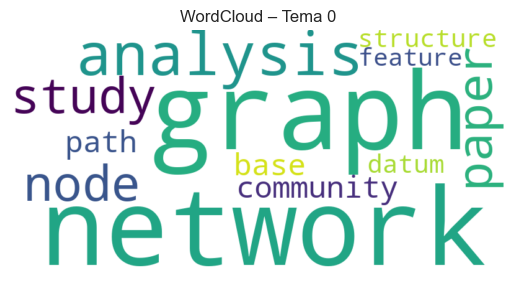

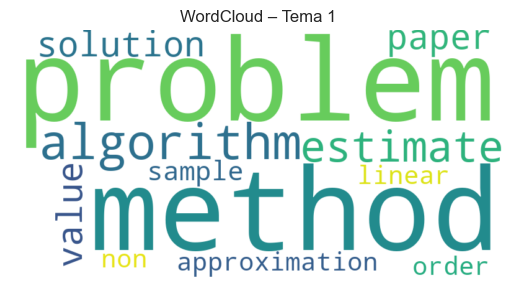

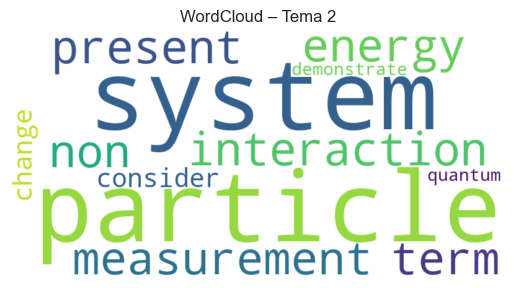

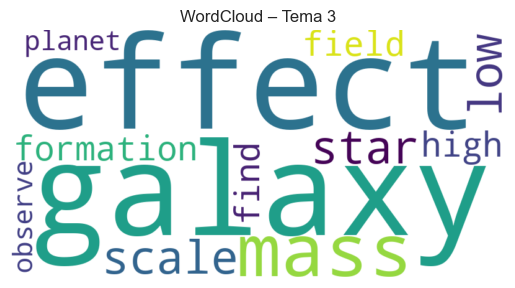

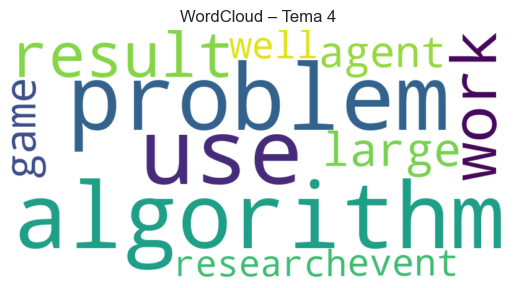

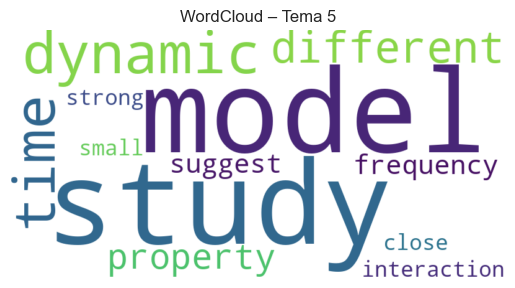

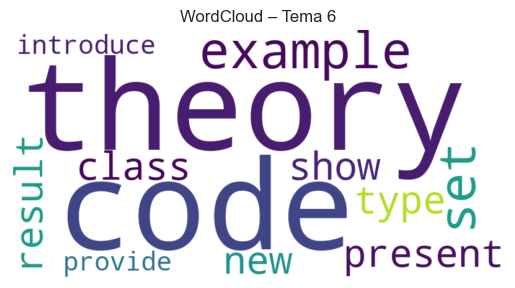

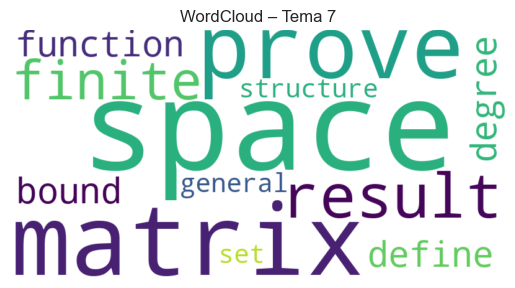

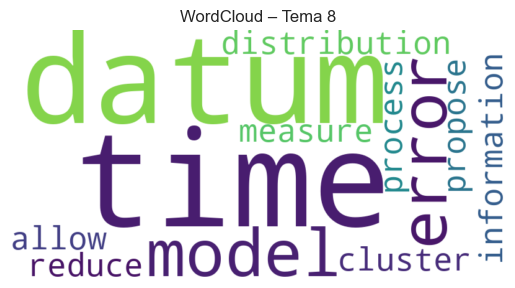

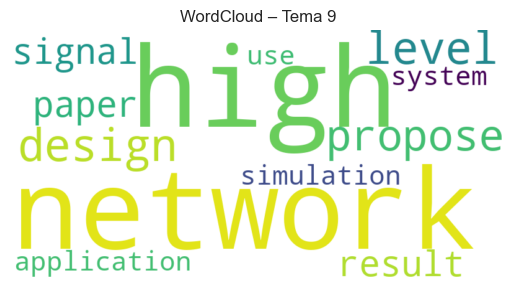

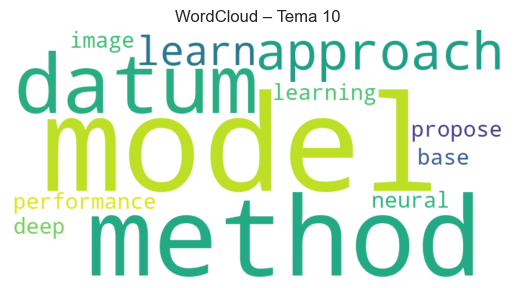

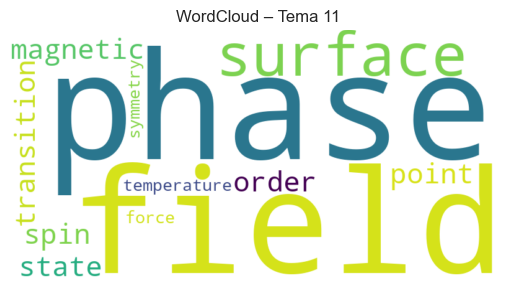

In [16]:
# Filtrar advertencias específicas
warnings.filterwarnings("ignore", category=DeprecationWarning, module="matplotlib")
for i, words in enumerate(topic_words_best):
    text = " ".join(words)
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure()
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud – Tema {i}")
    plt.show()

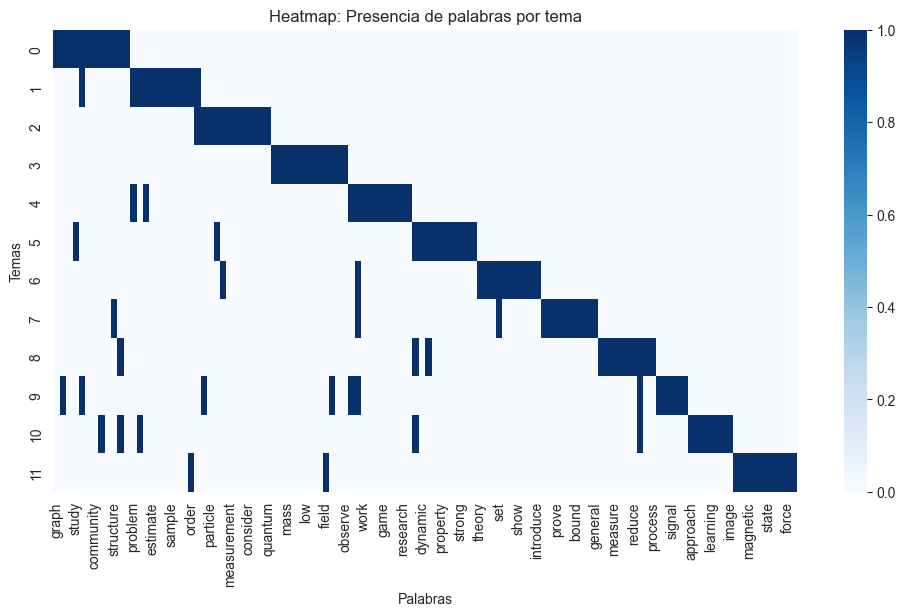

In [17]:
# Convertimos la lista en una matriz simple
# 1 = palabra presente en el top del tema
data = []

for words in topic_words_best:
    row = {w: 1 for w in words}
    data.append(row)

df_heat = pd.DataFrame(data).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(df_heat, cmap="Blues", annot=False)
plt.title("Heatmap: Presencia de palabras por tema")
plt.xlabel("Palabras")
plt.ylabel("Temas")
plt.show()

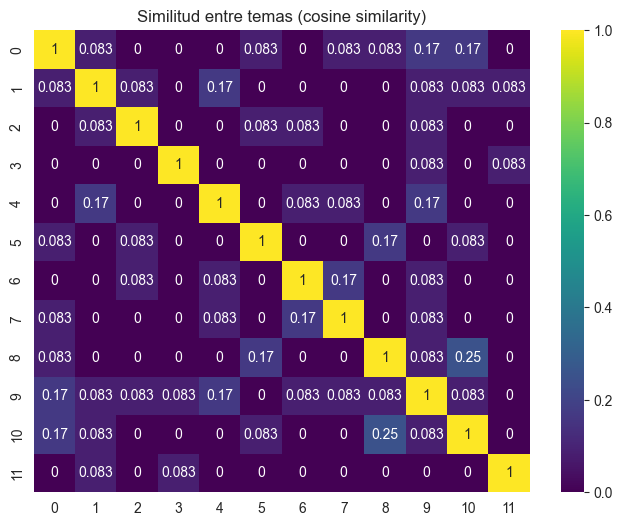

In [18]:
# Creamos vectores binarios de 0/1 para cada palabra
vocab = sorted(list({w for words in topic_words_best for w in words}))

topic_vectors = []
for words in topic_words_best:
    vec = [1 if v in words else 0 for v in vocab]
    topic_vectors.append(vec)

topic_vectors = np.array(topic_vectors)

# Similaridad coseno
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(topic_vectors)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, cmap="viridis")
plt.title("Similitud entre temas (cosine similarity)")
plt.show()

In [19]:
# best_model    -> modelo entrenado (python-lda)
# vocab_best    -> array/list con el vocabulario alineado con X_best
# X_best        -> matriz documento-término (scipy sparse) producida por CountVectorizer

# 1) topic_term_dists: matriz (n_topics x n_terms)
topic_term_dists = getattr(best_model, "topic_word_", None)
if topic_term_dists is None:
    raise RuntimeError("best_model no tiene atributo topic_word_. Asegúrate de que es un modelo python-lda entrenado.")

# Asegurarnos de que cada fila (topic) está normalizada a probabilidad (suma 1)
topic_term_dists = np.asarray(topic_term_dists, dtype=float)
row_sums = topic_term_dists.sum(axis=1, keepdims=True)
# evitar división por cero
row_sums[row_sums == 0] = 1.0
topic_term_dists = topic_term_dists / row_sums

# 2) doc_topic_dists: matriz (n_docs x n_topics)
doc_topic_dists = getattr(best_model, "doc_topic_", None)
if doc_topic_dists is None:
    # si no existe doc_topic_, a veces python-lda no lo guarda; intentar inferir con transform si está disponible
    if hasattr(best_model, "transform"):
        doc_topic_dists = best_model.transform(X_best)
    else:
        raise RuntimeError("best_model no expone doc_topic_ ni transform(). No se puede obtener doc-topic dists.")
doc_topic_dists = np.asarray(doc_topic_dists, dtype=float)

# 3) doc_lengths: número de tokens por documento (entero)
# X_best puede ser scipy sparse (n_docs x n_terms)
try:
    # .sum(axis=1) devuelve matriz columna; convertir a 1D
    doc_lengths = np.asarray(X_best.sum(axis=1)).ravel()
except Exception:
    # fallback: sumar por filas manualmente
    doc_lengths = np.array([int(x.sum()) for x in X_best])

# 4) vocab: lista de términos (en el orden de las columnas de X_best)
vocab = list(vocab_best)

# 5) term_frequency: frecuencia total de cada término en el corpus (longitud n_terms)
try:
    term_frequency = np.asarray(X_best.sum(axis=0)).ravel()
except Exception:
    term_frequency = np.array(X_best.sum(axis=0)).ravel()

# Comprobaciones básicas de shapes
n_topics, n_terms = topic_term_dists.shape
n_docs = doc_topic_dists.shape[0]
assert len(vocab) == n_terms, f"longitud vocab ({len(vocab)}) != n_terms ({n_terms})"
assert term_frequency.shape[0] == n_terms, "term_frequency no coincide con n_terms"
assert doc_lengths.shape[0] == n_docs, "doc_lengths no coincide con número de documentos"

# 6) Preparar y mostrar con pyLDAvis
vis = pyLDAvis.prepare(
    topic_term_dists,   # shape (n_topics, n_terms)
    doc_topic_dists,    # shape (n_docs, n_topics)
    doc_lengths,        # list/array longitud n_docs
    vocab,              # list de términos
    term_frequency,     # array longitud n_terms
    sort_topics=False
)

# Mostrar inline en notebook
pyLDAvis.display(vis)